**Exercise 6.4**

MNIST with fully connected networks and grid/random search

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tabulate import tabulate
from tensorflow.keras import layers

plt.style.use("seaborn-v0_8")

The MNIST data base of handwritten numbers is directly available through KERAS. The following codeblocks download and preprocess the data.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_valid = x_test[8000:]
y_valid = y_test[8000:]
x_test = x_test[:8000]
y_test = y_test[:8000]

# Hint: convert integer RGB values (0-255) to float values (0-1)


In [3]:
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_valid.shape[0], "validation samples")
print(x_test.shape[0], "test samples")

x_train shape: (60000, 28, 28)
60000 train samples
2000 validation samples
8000 test samples


In this exercise, a fully connected neural network is used to predict the handwritten numbers. To do this, we reformat the pictures with 28x28 pixels into a vector with a length of 28x28=784.

In [4]:
# reshape the image matrices to vectors
x_train = x_train.reshape(-1, 28**2)
x_valid = x_valid.reshape(-1, 28**2)
x_test = x_test.reshape(-1, 28**2)
print("x_train shape:", x_train.shape)

x_train shape: (60000, 784)


We use "onehot" encoding of the classes. This means a "zero" is encoded as `[1,0,0,0,0,0,0,0,0,0]` and a "one" as `[0,1,0,0,0,0,0,0,0,0]` etc.
This is done because our network will have ten output nodes with the output node with the largest value being the predicted number.

In [5]:
# convert class vectors to binary class matrices (10 numbers/classes)
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_valid_onehot = tf.keras.utils.to_categorical(y_valid, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)

In [6]:
# define model here
model = tf.keras.models.Sequential([
    layers.Dense(128, input_shape=(784,), activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    #layers.Dropout(0.3),
    layers.Dense(10),
    # softmax actication to transform output into probabilities
    layers.Activation('softmax')])

print(model.summary())

/opt/anaconda3/envs/mainenv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    # the recommended loss for a classification task is 'categorical_crossentropy'
    # (see lecture for details)
    loss='categorical_crossentropy',
    optimizer= opt,
    metrics=['accuracy']) # we use accuracy to quanitfy to network performance.

# define callbacks for training
save_best = tf.keras.callbacks.ModelCheckpoint(
    "best_model_{}.weights.h5".format(model.name),
    save_best_only=True,
    monitor="val_accuracy",
    save_weights_only=True,
)

# Keras calculates training accuracy and loss during the training and
# with regularization applied, while the validation metrics are calculated
# at the end of each epoch. This callback calculates the training metrics
# the same way as for the validation
class CalculateMetrics(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        train_loss, train_acc = model.evaluate(x_train, y_train_onehot, verbose=0)
        logs["train_loss"] = train_loss
        logs["train_acc"] = train_acc

results = model.fit(
    x_train, y_train_onehot,
    validation_data=(x_valid, y_valid_onehot),

    batch_size=128,
    epochs=10,
    callbacks=[
        save_best,
        CalculateMetrics(),
        tf.keras.callbacks.CSVLogger("history_{}.csv".format(model.name))
    ]
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8133 - loss: 1.7319 - val_accuracy: 0.9140 - val_loss: 0.3896 - train_loss: 0.4281 - train_acc: 0.8952
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9144 - loss: 0.3429 - val_accuracy: 0.9435 - val_loss: 0.2567 - train_loss: 0.2431 - train_acc: 0.9349
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9394 - loss: 0.2279 - val_accuracy: 0.9475 - val_loss: 0.2057 - train_loss: 0.1710 - train_acc: 0.9512
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9500 - loss: 0.1781 - val_accuracy: 0.9530 - val_loss: 0.1833 - train_loss: 0.1472 - train_acc: 0.9568
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9601 - loss: 0.1460 - val_accuracy: 0.9465 - val_loss: 0.2151 - train_loss: 0.1512 - train_acc: 0.9546
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9655 - loss: 0.1201 - val_accuracy: 0.9705 - val_loss: 0.1330 - train_loss: 0.0867 - trai

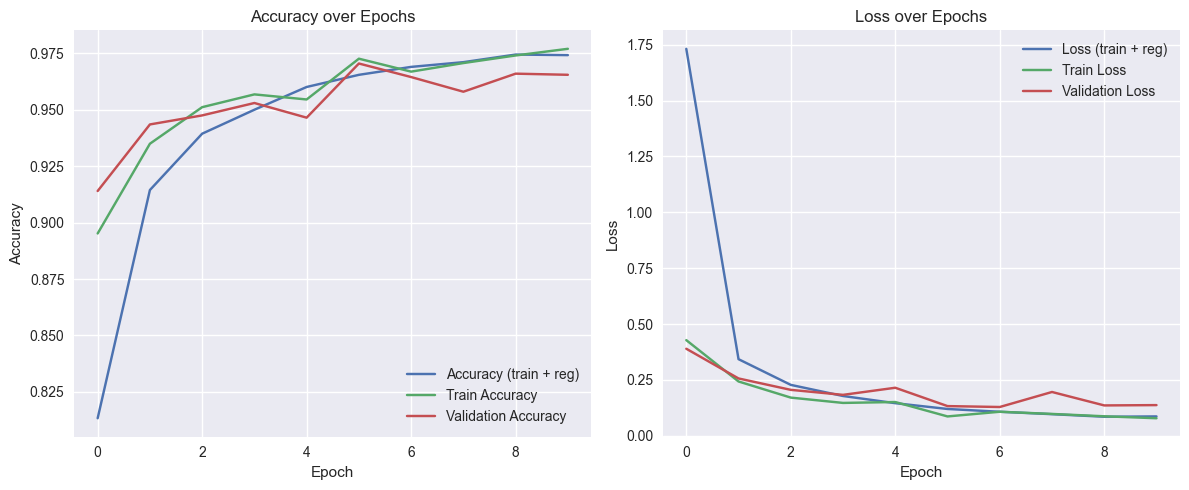

In [8]:
# load best model
model.load_weights(f"best_model_{model.name}.weights.h5")

# ------------------------
# ---     Plotting     ---
# ------------------------

# plot training history
history = np.genfromtxt(f"history_{model.name}.csv", delimiter=",", names=True)

# add plots below
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# Plot accuracy
ax1.plot(history['epoch'], history['accuracy'], label='Accuracy (train + reg)')
ax1.plot(history['epoch'], history['train_acc'], label='Train Accuracy')
ax1.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy over Epochs')
ax1.legend()
# Plot loss
ax2.plot(history['epoch'], history['loss'], label='Loss (train + reg)')
ax2.plot(history['epoch'], history['train_loss'], label='Train Loss')
ax2.plot(history['epoch'], history['val_loss'], label='Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Loss over Epochs')
ax2.legend()
plt.tight_layout()
plt.show()

In [9]:
# evaluate performance

print("Model performance :")
headers = ["", "Loss", "Accuracy", "Test error rate [%]"]

table = [
    [
        "Train",
        *model.evaluate(x_train, y_train_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_train, y_train_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Validation",
        *model.evaluate(x_valid, y_valid_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_valid, y_valid_onehot, verbose=0, batch_size=128)[1])
        * 100,
    ],
    [
        "Test",
        *model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128),
        (1 - model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)[1]) * 100,
    ],
]

print(tabulate(table, headers=headers, tablefmt="orgtbl"))

Model performance :
|            |      Loss |   Accuracy |   Test error rate [%] |
|------------+-----------+------------+-----------------------|
| Train      | 0.0866954 |   0.972633 |               2.73666 |
| Validation | 0.132977  |   0.9705   |               2.95    |
| Test       | 0.187561  |   0.9535   |               4.65    |


You can compare your own results with a variety of different models: http://yann.lecun.com/exdb/mnist/ and https://en.wikipedia.org/wiki/MNIST_database

### With the assigned network structures (30% Dropout)

Model performance for testing data :

Accuracy = 0.943375
Test error rate = 5.6625%

### With different structures (add two hidden layes with 64 nodes and 32 nodes, ReLu activation function)

Model performance for testing data :

Accuracy = 0.962125 
Test error rate = 3.7875%

The following codeblocks define some helper functions for plotting. You don't need to touch them

In [10]:
# @title
def plot_image(X, ax=None):
    """Plot an image X.

    Args:
        X (2D array): image, grayscale or RGB
        ax (None, optional): Description
    """
    if ax is None:
        ax = plt.gca()

    if (X.ndim == 2) or (X.shape[-1] == 1):
        ax.imshow(X.astype("uint8"), origin="upper", cmap=plt.cm.Greys)
    else:
        ax.imshow(X.astype("uint8"), origin="upper")

    ax.set(xticks=[], yticks=[])


def plot_prediction(Yp, X, y, classes=None, top_n=False):
    """Plot an image along with all or the top_n predictions.

    Args:
        Yp (1D array): predicted probabilities for each class
        X (2D array): image
        y (integer): true class label
        classes (1D array, optional): class names
        top_n (int, optional): number of top predictions to show
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.2))
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.15, top=0.98, wspace=0.02)
    plot_image(X, ax1)

    if top_n:
        n = top_n
        s = np.argsort(Yp)[-top_n:]
    else:
        n = len(Yp)
        s = np.arange(n)[::-1]

    patches = ax2.barh(np.arange(n), Yp[s], align="center")
    ax2.set(xlim=(0, 1), xlabel="Probability", yticks=[])

    for iy, patch in zip(s, patches):
        if iy == y:
            patch.set_facecolor("C1")  # color correct patch

    if classes is None:
        classes = np.arange(0, np.size(Yp))

    for i in range(n):
        ax2.text(0.05, i, classes[s][i], ha="left", va="center")

    plt.show()


def plot_confusion(yp, y, classes=None, fname=None):
    """Plot confusion matrix for given true and predicted class labels

    Args:
        yp (1D array): predicted class labels
        y (1D array): true class labels
        classes (1D array): class names
        fname (str, optional): filename for saving the plot
    """
    if classes is None:
        n = max(max(yp), max(y)) + 1
        classes = np.arange(n)
    else:
        n = len(classes)

    bins = np.linspace(-0.5, n - 0.5, n + 1)
    C = np.histogram2d(y, yp, bins=bins)[0]
    C = C / np.sum(C, axis=0) * 100

    _ = plt.figure(figsize=(8, 8))
    plt.imshow(C, interpolation="nearest", vmin=0, vmax=100, cmap=plt.cm.YlGnBu)
    plt.gca().set_aspect("equal")
    cbar = plt.colorbar(shrink=0.8)
    cbar.set_label("Frequency %")
    plt.xlabel("Prediction")
    plt.ylabel("Truth")
    plt.xticks(range(n), classes, rotation="vertical")
    plt.yticks(range(n), classes)
    for x in range(n):
        for y in range(n):
            if np.isnan(C[x, y]):
                continue
            color = "white" if x == y else "black"
            plt.annotate(
                "%.1f" % (C[x, y]), xy=(y, x), color=color, ha="center", va="center"
            )

    plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


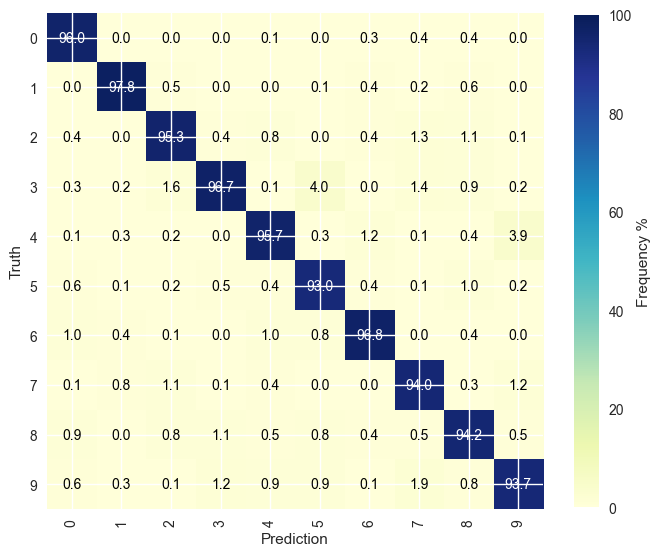

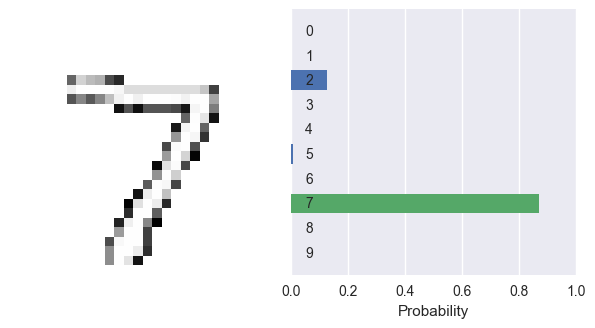

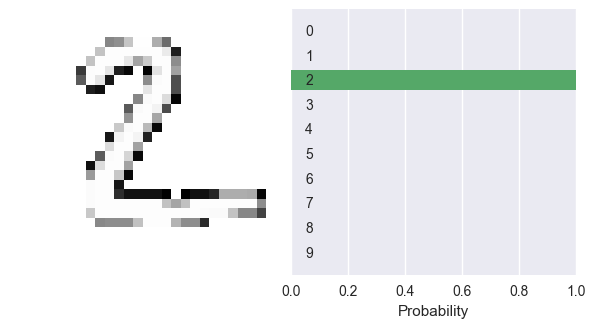

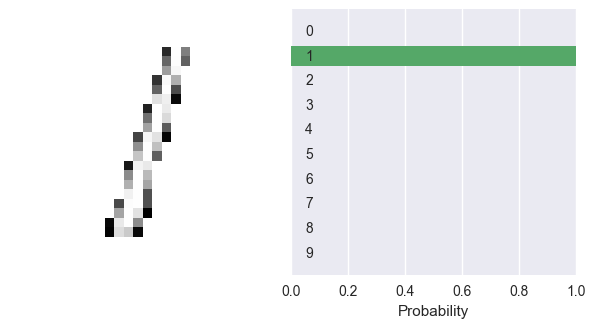

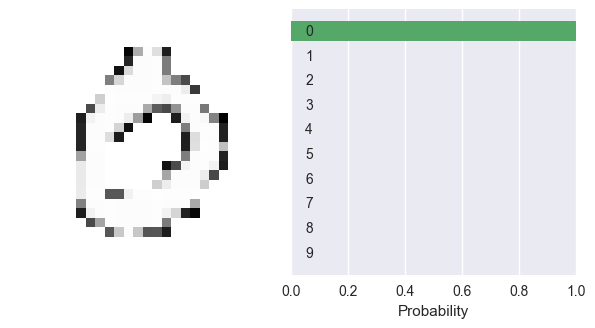

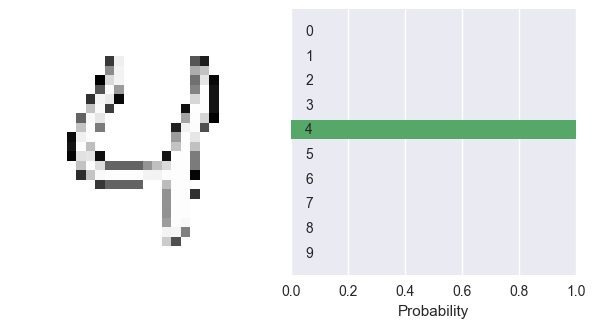

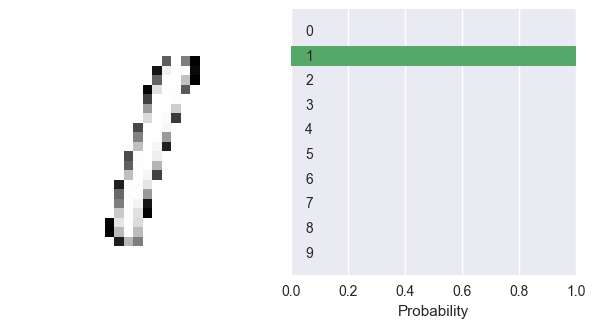

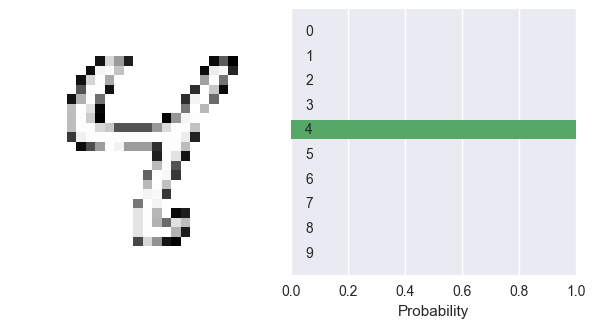

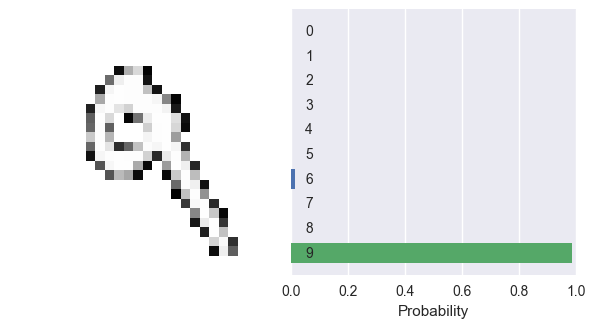

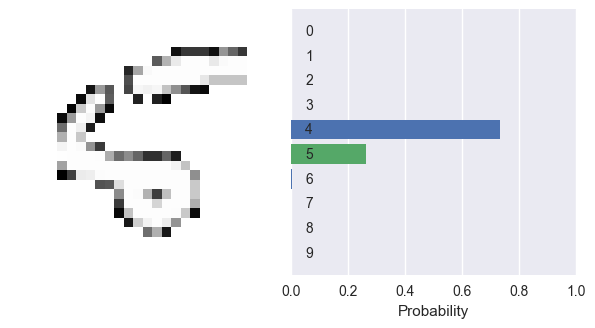

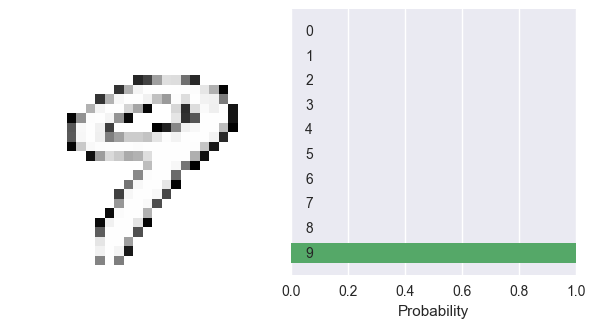

In [11]:
# plot a few examples, loop over test dataset:
# get missidentified samples
output = model.predict(x_test, batch_size=128)
labels = np.argmax(y_test_onehot, axis=1)
predictions = np.argmax(output, axis=1)
plot_confusion(predictions, labels)

for i in range(10): # loop over first 10 test samples
    plot_prediction(output[i],
                    255 * np.reshape(x_test[i], (28, 28)), # we need to reshape the data into an image and convert back to RGB color scale by multiplying with 255
                    labels[i])


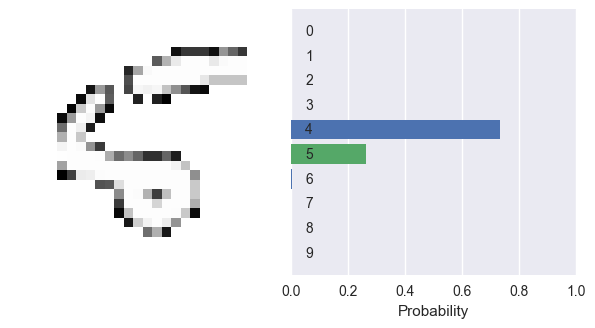

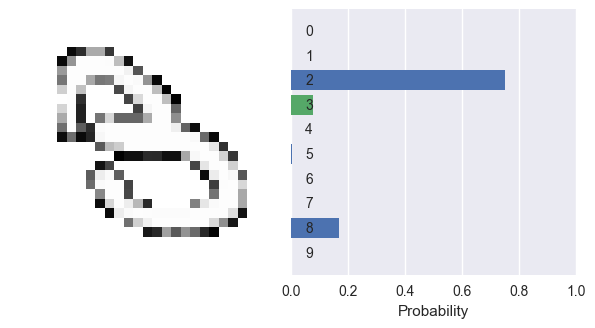

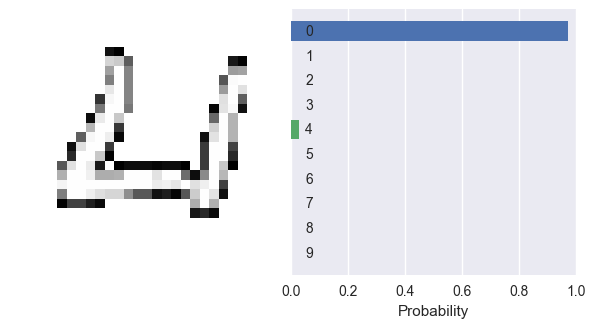

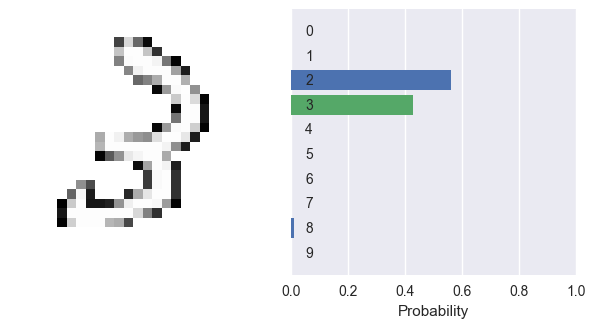

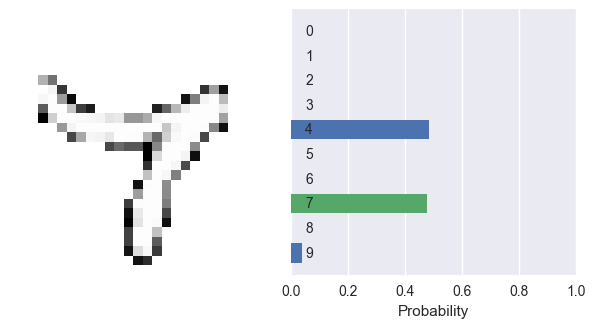

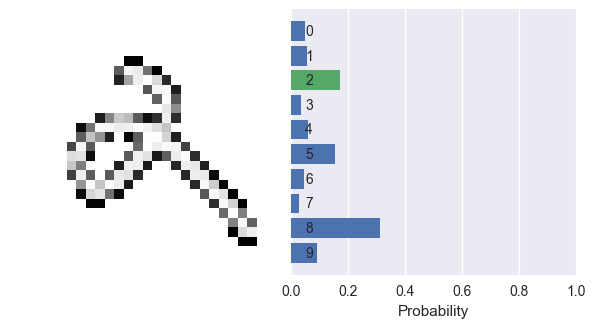

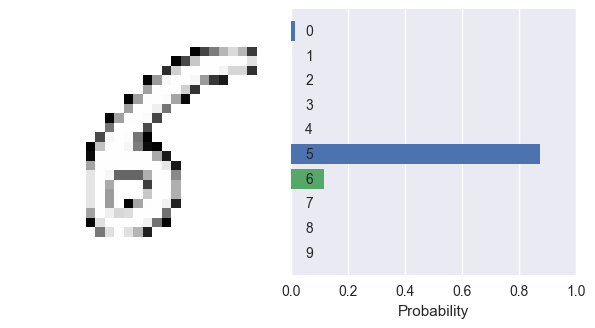

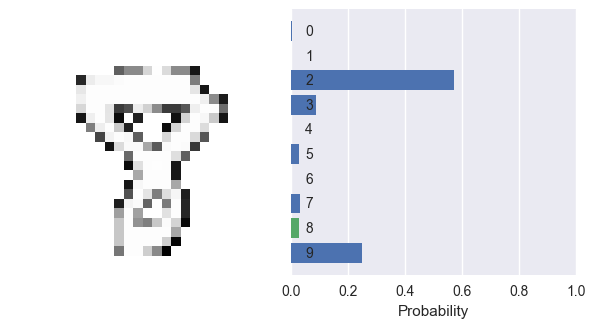

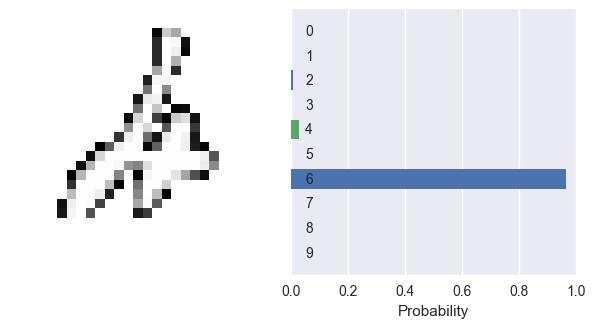

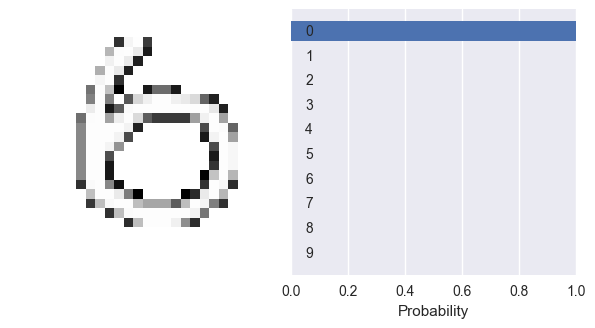

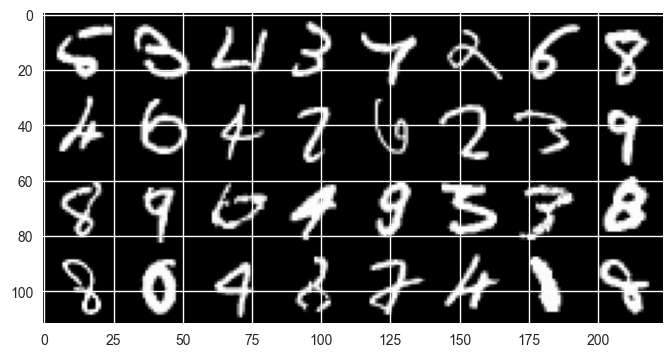

In [12]:
# now plot a few examples that were misclassified

indices_miss = np.nonzero(predictions != labels)[0]
x_missid = x_test[indices_miss]

for i in indices_miss[:10]:
    plot_prediction(output[i],
                    255 * np.reshape(x_test[i], (28, 28)), # we need to reshape the data into an image and convert back to RGB color scale by multiplying with 255
                    labels[i])

# or plot 32 of them in a joint plot
fig = plt.figure()
ax = fig.add_subplot(111)
plotdata = x_missid[:32]
plotdata = np.hstack(np.concatenate(np.reshape(plotdata, (4, 8, 28, 28)), axis=1))
ax.imshow(plotdata, cmap="gray")


**Grid search**

Let's search the two hyperparameters dropout and number of nodes. You can start from the template below.



In [13]:
#slecteted hyperparameters : dropouts and number of nodes
dropout_values = [0.1, 0.3, 0.5, 0.7]
n_neurons_values = [32, 64, 128, 256]


results_gridsearch = np.zeros((len(dropout_values), len(n_neurons_values), 2))
for iDrop, drop in enumerate(dropout_values):
  for iN, n_neurons in enumerate(n_neurons_values):
    model = tf.keras.models.Sequential([
        layers.Dense(n_neurons, input_shape=(784,), activation='relu'),
        layers.Dropout(drop),
        layers.Dense(10),
        # softmax actication to transform output into probabilities
        layers.Activation('softmax')])

    opt = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(
        # the recommended loss for a classification task is 'categorical_crossentropy'
        # (see lecture for details)
        loss='categorical_crossentropy',
        optimizer=opt,
        metrics=['accuracy']) # we use accuracy to quanitfy to network performance.

    results = model.fit(
        x_train, y_train_onehot,
        validation_data=(x_valid, y_valid_onehot),
        batch_size=128,
        epochs=10,
        verbose=0
        )
    t = model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)
    results_gridsearch[iDrop, iN] = t
    print(f"dropout = {drop:.2f}, {n_neurons} neurons -> accuracy {results_gridsearch[iDrop, iN][1]:.3f}, error rate = {100*(1-results_gridsearch[iDrop, iN][1]):.1f}%")


/opt/anaconda3/envs/mainenv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


dropout = 0.10, 32 neurons -> accuracy 0.896, error rate = 10.4%
dropout = 0.10, 64 neurons -> accuracy 0.933, error rate = 6.7%
dropout = 0.10, 128 neurons -> accuracy 0.947, error rate = 5.3%
dropout = 0.10, 256 neurons -> accuracy 0.956, error rate = 4.4%
dropout = 0.30, 32 neurons -> accuracy 0.861, error rate = 13.9%
dropout = 0.30, 64 neurons -> accuracy 0.932, error rate = 6.8%
dropout = 0.30, 128 neurons -> accuracy 0.942, error rate = 5.8%
dropout = 0.30, 256 neurons -> accuracy 0.953, error rate = 4.7%
dropout = 0.50, 32 neurons -> accuracy 0.781, error rate = 21.9%
dropout = 0.50, 64 neurons -> accuracy 0.909, error rate = 9.1%
dropout = 0.50, 128 neurons -> accuracy 0.931, error rate = 6.9%
dropout = 0.50, 256 neurons -> accuracy 0.939, error rate = 6.1%
dropout = 0.70, 32 neurons -> accuracy 0.313, error rate = 68.7%
dropout = 0.70, 64 neurons -> accuracy 0.692, error rate = 30.8%
dropout = 0.70, 128 neurons -> accuracy 0.876, error rate = 12.4%
dropout = 0.70, 256 neurons

### The best combination of hyperparameters is 256 neurons with 10% dropout layer : accuracy = 0.953

**Random seach**

Now lets implement a random search. A random search allows us to scan more hyperparameters at once without more computing time. You can start from the template below.




In [14]:
N = 20 # number of trials
search = {
    'batch_size': np.random.choice([16, 32, 64, 128, 256], N),
    'num_neurons': np.random.choice([8, 32, 128, 256, 512], N),
    'learn_rate': np.random.choice([-5,-4, -3, -2, -1],N),
    'activation': np.random.choice(['relu', 'elu', 'sigmoid', 'tanh'], N),
    'dropout': np.random.choice([0.0, 0.1, 0.2, 0.3, 0.5, 0.6], N),
    'val_acc': np.zeros(N)
}

for i in range(N):
  # you can access the current value of the hyperparameter with `search['batch_size'][i]`
  model = tf.keras.models.Sequential([
                      tf.keras.layers.Dense(int(search['num_neurons'][i]), input_shape=(784,), activation=search['activation'][i]),
                      tf.keras.layers.Dropout(float(search['dropout'][i])),
                      tf.keras.layers.Dense(10, activation='softmax')])
  model.compile(loss='categorical_crossentropy',
                optimizer= tf.keras.optimizers.Adam(learning_rate=10 ** float(search['learn_rate'][i])),
                metrics=['accuracy'])
  results = model.fit(
        x_train, y_train_onehot,
        validation_data=(x_valid, y_valid_onehot),
        batch_size=int(search['batch_size'][i]),
        epochs=10,
        verbose=0
      )
  search['val_acc'][i] = model.evaluate(x_test, y_test_onehot, verbose=0, batch_size=128)[1]
  print(f"iteration {i}:")
  for key in search:
    print(f"\t{key}: {search[key][i]}")
  print(f"\t-> accuracy {search['val_acc'][i]:.3f}, error rate = {100*(1-search['val_acc'][i]):.1f}%")


iteration 0:
	batch_size: 256
	num_neurons: 8
	learn_rate: -3
	activation: tanh
	dropout: 0.6
	val_acc: 0.7481250166893005
	-> accuracy 0.748, error rate = 25.2%
iteration 1:
	batch_size: 16
	num_neurons: 256
	learn_rate: -1
	activation: sigmoid
	dropout: 0.6
	val_acc: 0.1835000067949295
	-> accuracy 0.184, error rate = 81.6%
iteration 2:
	batch_size: 32
	num_neurons: 128
	learn_rate: -3
	activation: elu
	dropout: 0.2
	val_acc: 0.9312499761581421
	-> accuracy 0.931, error rate = 6.9%
iteration 3:
	batch_size: 128
	num_neurons: 256
	learn_rate: -3
	activation: sigmoid
	dropout: 0.1
	val_acc: 0.9412500262260437
	-> accuracy 0.941, error rate = 5.9%
iteration 4:
	batch_size: 16
	num_neurons: 8
	learn_rate: -3
	activation: elu
	dropout: 0.3
	val_acc: 0.210875004529953
	-> accuracy 0.211, error rate = 78.9%
iteration 5:
	batch_size: 16
	num_neurons: 32
	learn_rate: -1
	activation: tanh
	dropout: 0.1
	val_acc: 0.19987499713897705
	-> accuracy 0.200, error rate = 80.0%
iteration 6:
	batch_siz

### the best network setting is : (might be different when repeated)
    batch_size: 64
	num_neurons: 512
	learn_rate: -3
	activation: elu
	dropout: 0.0

In [15]:
#Create function to return the loss

def run_random_search(N):
    best_val_loss = float('inf')
    search = {
        'batch_size': np.random.choice([16, 32, 64, 128, 256], N),
        'num_neurons': np.random.choice([8, 32, 128, 256, 512], N),
        'learn_rate': np.random.choice([-5,-4, -3, -2, -1],N),
        'activation': np.random.choice(['relu', 'elu', 'sigmoid', 'tanh'], N),
        'dropout': np.random.choice([0.0, 0.1, 0.2, 0.3, 0.5, 0.6], N),
    }
    
    for i in range(N):
        model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(int(search['num_neurons'][i]), input_shape=(784,), activation=search['activation'][i]),
            tf.keras.layers.Dropout(float(search['dropout'][i])),
            tf.keras.layers.Dense(10, activation='softmax')
        ])
       
        lr = 10.0 ** search['learn_rate'][i]
        model.compile(loss='categorical_crossentropy',
                      optimizer=tf.keras.optimizers.Adam(learning_rate=lr))
        
        model.fit(
            x_train, y_train_onehot,
            validation_data=(x_valid, y_valid_onehot),
            batch_size=int(search['batch_size'][i]),
            epochs=2, 
            verbose=0
        )
        val_loss = model.evaluate(x_valid, y_valid_onehot, verbose=0, batch_size=128)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
    return best_val_loss

In [16]:
n_values = [10, 20, 30, 40, 50]
num_repeats = 3

mean_losses = []
std_losses = []

for n in n_values:
    losses = []
    print(f"Testing N={n}")
    for rep in range(num_repeats):
        loss = run_random_search(n)
        losses.append(loss)
        print(f"  Rep {rep}: best_val_loss={loss:.4f}")
    mean_losses.append(np.mean(losses))
    std_losses.append(np.std(losses))

print("Means:", mean_losses)
print("Stds:", std_losses)

Testing N=10
  Rep 0: best_val_loss=0.2168
  Rep 1: best_val_loss=0.2173
  Rep 2: best_val_loss=0.3591
Testing N=20
  Rep 0: best_val_loss=0.2209
  Rep 1: best_val_loss=0.2007
  Rep 2: best_val_loss=0.1972
Testing N=30
  Rep 0: best_val_loss=0.1769
  Rep 1: best_val_loss=0.2708
  Rep 2: best_val_loss=0.2292
Testing N=40
  Rep 0: best_val_loss=0.2097
  Rep 1: best_val_loss=0.2155
  Rep 2: best_val_loss=0.1818
Testing N=50
  Rep 0: best_val_loss=0.2072
  Rep 1: best_val_loss=0.1899
  Rep 2: best_val_loss=0.1878
Means: [np.float64(0.2644069592158), np.float64(0.2062429984410604), np.float64(0.225627268354098), np.float64(0.20233472188313803), np.float64(0.1949308713277181)]
Stds: [np.float64(0.06696265797370103), np.float64(0.010434070686040187), np.float64(0.03840789292686247), np.float64(0.014696351577330237), np.float64(0.008695445683022465)]


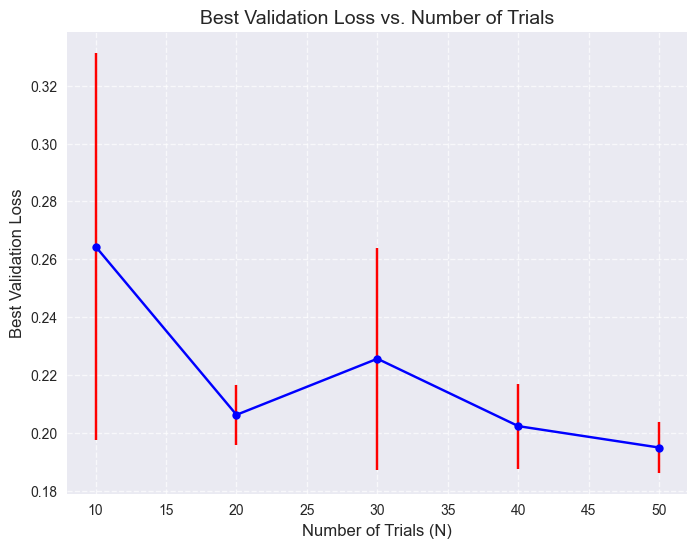

In [ ]:
# Best val loss plot
plt.figure(figsize=(8, 6))
# Plot mean validation losses with standard deviation as error bars
plt.errorbar(n_values, mean_losses, yerr=std_losses, 
             fmt='-o',          # Line with circle markers
             capsize=5,         # Caps on the error bars
             ecolor='red',      # Color of the error bars
             color='blue',      # Color of the main line/markers
             markersize=6)

plt.xlabel('Number of Trials (N)', fontsize=12)
plt.ylabel('Best Validation Loss', fontsize=12)
plt.title('Best Validation Loss vs. Number of Trials', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
# Display the plot
plt.show()